In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Data.zip to Data.zip


In [ ]:
!unzip -q Data.zip -d Data


In [ ]:
import os
import numpy as np

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

1️⃣ Load & Preprocess Data


In [ ]:
import math
import os
import numpy as np

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Dataset directories
BASE_DIR = "Data"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")

# Image size and batch size
IMG_SIZE = (224, 224)  # Optimal size for EfficientNetB0
BATCH_SIZE = 32

# Data Augmentation for Training
# NOTE: EfficientNetB0 expects pixel values in [0, 255] (it has built-in preprocessing)
# so we do NOT rescale here; the model's preprocess_input handles normalization internally.
train_datagen = ImageDataGenerator(
    # removed rescale=1./255 as EfficientNetB0 handles its own preprocessing
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True  # Added for better generalization
)

# No rescaling for Testing — shuffle=False ensures labels align with predictions
test_datagen = ImageDataGenerator(
    # removed rescale=1./255 as EfficientNetB0 handles its own preprocessing
)

# Load Training Data
train_generator = train_datagen.flow_from_directory(
    directory=TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"  # Binary classification: Benign vs Malignant
)

# Load Testing Data — shuffle=False is CRITICAL so predictions align with true labels
test_generator = test_datagen.flow_from_directory(
    directory=TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False  # Must be False for correct evaluation
)

# Print class labels
print("Class Mapping:", train_generator.class_indices)

Found 11879 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.
Class Mapping: {'Benign': 0, 'Malignant': 1}


2️⃣ Exploratory Data Analysis (EDA)


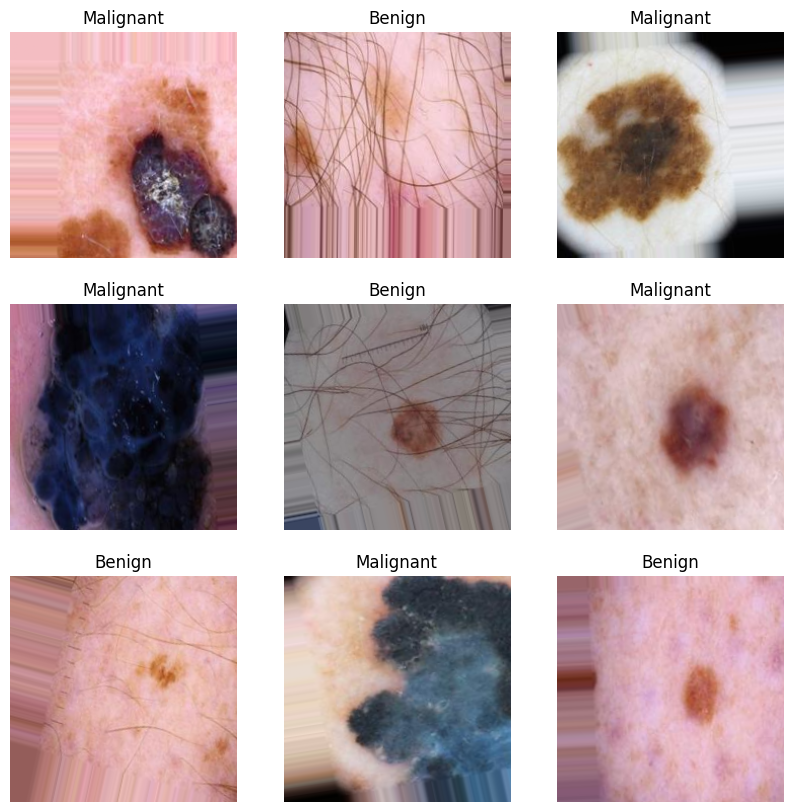

In [ ]:
def plot_images(generator):
    images, labels = next(generator)  # Get a batch
    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i+1)
        # Normalize image to [0, 1] for display if it's not already
        # EfficientNetB0 handles its own preprocessing internally, so the ImageDataGenerator doesn't rescale
        # but for displaying with matplotlib, we need to rescale manually.
        plt.imshow(images[i] / 255.0)
        plt.title("Malignant" if labels[i] == 1 else "Benign")
        plt.axis("off")
    plt.show()

# Plot Training Images
plot_images(train_generator)

3️⃣ Build CNN Model using Transfer Learning (EfficientNetB0)

**Key improvement:** Instead of training a small CNN from scratch, we use EfficientNetB0
pre-trained on ImageNet as a feature extractor. This gives us powerful learned features
without needing millions of training samples. We freeze the base model and only train
the classification head.

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0

# Load EfficientNetB0 pre-trained on ImageNet, without the top classification layer
base_model = EfficientNetB0(
    weights='imagenet',        # Use ImageNet pre-trained weights
    include_top=False,         # Exclude the final classification layer
    input_shape=(224, 224, 3)  # Match our image size
)

# Freeze the base model — don't update pre-trained weights during initial training
base_model.trainable = False

# Build the classification head on top of EfficientNetB0
model = models.Sequential([
    base_model,

    # Global Average Pooling instead of Flatten to reduce parameters
    layers.GlobalAveragePooling2D(),

    # Fully Connected Layers
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),  # Dropout to reduce overfitting

    layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Model Summary
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,788 (16.70 MB)

 Trainable params: 328,705 (1.25 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

4️⃣ Train Model — Phase 1: Train only the classification head (base model frozen)

In [ ]:
# EarlyStopping to stop training when the model stops improving
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,  # Stop training after 5 epochs with no improvement
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau to reduce the learning rate if the model stops improving
lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,  # Reduce LR if no improvement after 3 epochs
    min_lr=1e-7,
    verbose=1
)

# Calculate steps per epoch and validation steps using math.ceil for robustness
steps_per_epoch_train = int(np.ceil(train_generator.samples / BATCH_SIZE))
validation_steps_test = int(np.ceil(test_generator.samples / BATCH_SIZE))

# Phase 1: Train only the head (base model frozen)
print("Phase 1: Training classification head with frozen base model...")
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch_train,
    epochs=10,
    validation_data=test_generator,
    validation_steps=validation_steps_test,
    callbacks=[early_stopping, lr_scheduler]
)

Phase 1: Training classification head with frozen base model...
Epoch 1/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 209s 483ms/step - accuracy: 0.8434 - loss: 0.3770 - val_accuracy: 0.8155 - val_loss: 0.3734 - learning_rate: 0.0010
Epoch 2/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 145s 388ms/step - accuracy: 0.8627 - loss: 0.3160 - val_accuracy: 0.8285 - val_loss: 0.3465 - learning_rate: 0.0010
Epoch 3/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 147s 396ms/step - accuracy: 0.8677 - loss: 0.3020 - val_accuracy: 0.8810 - val_loss: 0.2801 - learning_rate: 0.0010
Epoch 4/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 150s 403ms/step - accuracy: 0.8741 - loss: 0.2943 - val_accuracy: 0.9015 - val_loss: 0.2568 - learning_rate: 0.0010
Epoch 5/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 145s 390ms/step - accuracy: 0.8752 - loss: 0.2920 - val_accuracy: 0.8960 - val_loss: 0.2570 - learning_rate: 0.0010
Epoch 6/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 145s 389ms/step - accuracy: 0.8790 - loss: 0.2898 - val_accuracy: 0.8865 - val_loss: 0.2694 - learning_rate: 0.0010


5️⃣ Fine-Tuning — Phase 2: Unfreeze top layers of EfficientNetB0 and fine-tune

After the head has learned, we unfreeze the top layers of the base model and
fine-tune with a very low learning rate for additional accuracy gains.

In [ ]:
# Unfreeze the base model for fine-tuning
base_model.trainable = True

# Freeze all layers except the last 20 (fine-tune only top layers)
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with a much lower learning rate for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Reset the test generator before fine-tuning validation
test_generator.reset()

# Calculate steps per epoch and validation steps using math.ceil for robustness
steps_per_epoch_fine_tune = int(np.ceil(train_generator.samples / BATCH_SIZE))
validation_steps_fine_tune = int(np.ceil(test_generator.samples / BATCH_SIZE))

# To prevent 'Your input ran out of data' warnings with ImageDataGenerator over multiple epochs,
# it's best to wrap them in a tf.data.Dataset with .repeat().
# Define generator functions that yield indefinitely
def train_gen_fn():
    while True:
        yield from train_generator

def test_gen_fn():
    while True:
        yield from test_generator

# Create tf.data.Dataset from generators
train_dataset = tf.data.Dataset.from_generator(
    train_gen_fn,
    output_types=(tf.float32, tf.float32),
    output_shapes=(
        tf.TensorShape([None, IMG_SIZE[0], IMG_SIZE[1], 3]),
        tf.TensorShape([None])
    )
).repeat() # Repeat the dataset indefinitely

validation_dataset = tf.data.Dataset.from_generator(
    test_gen_fn,
    output_types=(tf.float32, tf.float32),
    output_shapes=(
        tf.TensorShape([None, IMG_SIZE[0], IMG_SIZE[1], 3]),
        tf.TensorShape([None])
    )
).repeat() # Repeat the dataset indefinitely

# Phase 2: Fine-tune the model
print("Phase 2: Fine-tuning top layers of EfficientNetB0...")
history_fine = model.fit(
    train_dataset, # Use the new tf.data.Dataset
    steps_per_epoch=steps_per_epoch_fine_tune,
    epochs=20,
    validation_data=validation_dataset, # Use the new tf.data.Dataset
    validation_steps=validation_steps_fine_tune,
    callbacks=[early_stopping, lr_scheduler]
)

Phase 2: Fine-tuning top layers of EfficientNetB0...
Epoch 1/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 208s 488ms/step - accuracy: 0.8748 - loss: 0.3004 - val_accuracy: 0.8770 - val_loss: 0.2875 - learning_rate: 1.0000e-05
Epoch 2/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 148s 398ms/step - accuracy: 0.8756 - loss: 0.2979 - val_accuracy: 0.8825 - val_loss: 0.2718 - learning_rate: 1.0000e-05
Epoch 3/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.8817 - loss: 0.2905
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
372/372 ━━━━━━━━━━━━━━━━━━━━ 145s 389ms/step - accuracy: 0.8781 - loss: 0.2939 - val_accuracy: 0.8830 - val_loss: 0.2693 - learning_rate: 1.0000e-05
Epoch 4/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 144s 387ms/step - accuracy: 0.8790 - loss: 0.2832 - val_accuracy: 0.8830 - val_loss: 0.2712 - learning_rate: 3.0000e-06
Epoch 5/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 146s 391ms/step - accuracy: 0.8773 - loss: 0.2873 - val_accuracy: 0.8805 - val_loss: 0.2737 - learning_rate: 3.00

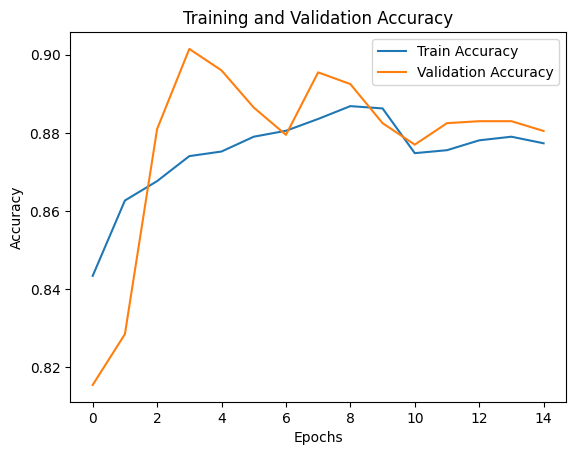

In [ ]:
# Save Model
model.save("skin_cancer_efficientnet.keras")

# Combine both training histories for plotting
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

# Plot Training History
plt.plot(acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")
plt.show()

6️⃣ Evaluate Model

**Important fix:** We reset the test generator before predicting to ensure
predictions are aligned with the true labels. Without `shuffle=False` and
resetting the generator, predictions and labels get misaligned — this was
the root cause of the original 49% accuracy.

63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 156ms/step
Classification Report:
              precision    recall  f1-score   support

      Benign       0.84      0.93      0.88      1000
   Malignant       0.92      0.83      0.87      1000

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000



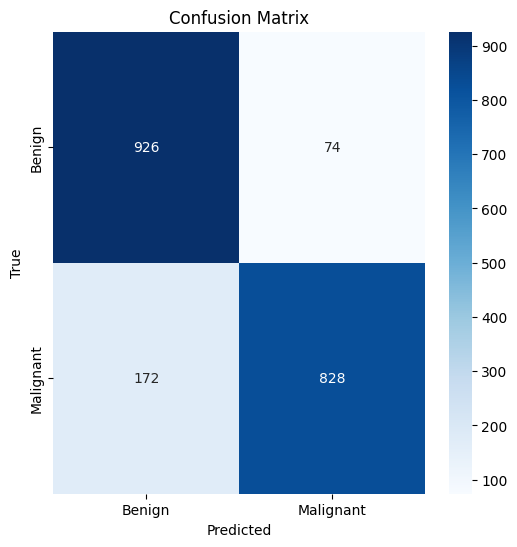

In [ ]:
# IMPORTANT: Reset the generator before predicting to ensure alignment
test_generator.reset()

# Predict on the full test set
test_pred = model.predict(
    test_generator,
    steps=np.ceil(test_generator.samples / BATCH_SIZE).astype(int),
    verbose=1
)

# Convert predictions to binary labels (0 or 1)
test_pred_labels = (test_pred > 0.5).astype("int32").flatten()

# Get the true labels — use all samples (generator was NOT shuffled)
test_true_labels = test_generator.classes

# Match prediction length to true label count (ceiling division may add one extra batch)
test_pred_labels = test_pred_labels[:len(test_true_labels)]

# Classification report
class_names = list(train_generator.class_indices.keys())
print("Classification Report:")
print(classification_report(test_true_labels, test_pred_labels, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(test_true_labels, test_pred_labels)

# Plot Confusion Matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load the saved model
model = load_model('skin_cancer_efficientnet.keras')


def predict_skin_cancer(image_path, model):
    img = image.load_img(image_path, target_size=(224, 224))  # Load Image
    img_array = image.img_to_array(img) / 255.0  # Normalize
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

    # Make Prediction
    prediction = model.predict(img_array)
    confidence = float(prediction[0][0])
    class_label = "Malignant" if confidence > 0.5 else "Benign"

    # Show Image with Prediction
    plt.imshow(img)
    plt.title(f"Predicted: {class_label} (confidence: {confidence:.2f})")
    plt.axis("off")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


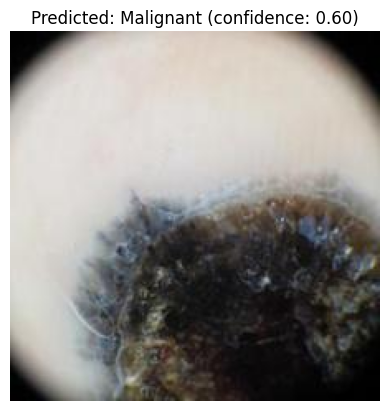

In [ ]:
predict_skin_cancer("Data/test/Malignant/5606.jpg", model)